# Banca

> Data: **2025-10-24**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Carica in un dataframe il file "bank.csv" (preso da [Kaggle](https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers)) che contiene dati relativi ai
clienti di una banca. Lo scopo è predire se il cliente abbandonerà la banca (feature `Exited`).

### Imports

In [ ]:
!curl -sLo dataset.zip "https://www.kaggle.com/api/v1/datasets/download/mathchi/churn-for-bank-customers"
!unzip -o dataset.zip
!mv churn.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: churn.csv               


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


#### Instances

In [ ]:
df.shape

(10000, 14)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


<Axes: >

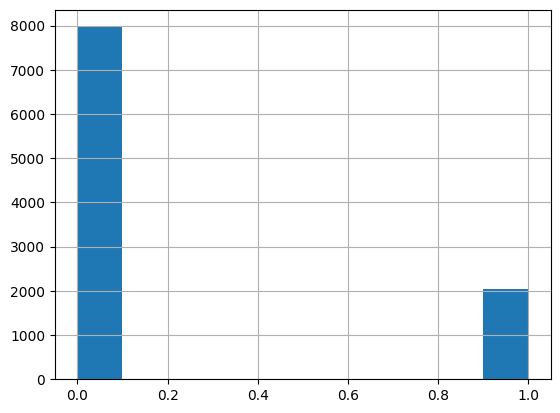

In [ ]:
df["Exited"].hist()

##

---

## Parte 2: Trasformazione e Predizione

### Domanda 01

Quante righe e quante colonne sono presenti? Ci sono valori nulli? Il dataset è bilanciato rispetto
alla classe da predire?

#### Quante righe e quante colonne sono presenti?

In [ ]:
df.shape

(10000, 14)

#### Ci sono valori nulli?

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Il dataset è bilanciato rispetto alla classe da predire?

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


---

### Domanda 02

Converti i valori di Gender in numerici (Male = 0, Female = 1).

In [ ]:
df["Gender"] = df["Gender"].map({ "Male": 0, "Female": 1 })
df["Gender"].head()

,Gender
0,1
1,1
2,1
3,1
4,1


---

### Domanda 03

Trasforma la feature Geography con OneHotEncoder.

In [ ]:
encoder = OneHotEncoder(dtype=int)

encoded = encoder.fit_transform(df[["Geography"]])
encoded

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10000 stored elements and shape (10000, 3)>

In [ ]:
geography_one_hot = pd.DataFrame.sparse.from_spmatrix(
    encoded,
    columns=encoder.get_feature_names_out()
)
geography_one_hot.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1,0,0
1,0,0,1
2,1,0,0
3,1,0,0
4,0,0,1


In [ ]:
df = pd.concat([df, geography_one_hot], axis=1)
df.drop("Geography", axis=1, inplace=True)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,2,15647311,Hill,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,3,15619304,Onio,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,4,15701354,Boni,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,5,15737888,Mitchell,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [ ]:
# Alternative method with get_dummies
# df = pd.get_dummies(df, columns=["Geography"], dtype=int)
# df.head()

---

### Domanda 04

Elimina le feature `RowNumber`, `CustomerId`, `Surname` e dividi il dataset in train (75% del dataset) e test (25%). Usa *random_state=0*.

In [ ]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [ ]:
# .to_numpy() for warning in DecisionTreeClassifier
X, y = df.drop("Exited", axis=1).to_numpy(), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0, stratify=y)

> L'argomento `stratify` di `train_test_split`, assegnato con la variabile permette di suddividere il dataset utilizzando la stessa proporzione di train e test che è presente nel dataset iniziale. Questo vuole dire che se nel dataset iniziale la variabile target, ovvero `Exited`, ha come proporzioni 80% di 1 e 20% di 0, allora anche il dataset di train e test presenteranno le stesse proporzioni per questa variabile target, ovvero entrambi presenteranno 80% di istanze con `Exited` pari a 1 e il 20% pari a 0.

---

### Domanda 05

Allena un decision tree per predire l'abbandono dei clienti, scegli tu i valori dei parametri e calcola l'accuratezza della predizione.

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=0)
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.8016

---

### Domanda 06

Aggiungi una nuova feature nel dataset con il valore di `(EstimatedSalary * Tenure + Balance) / 2`. L’accuratezza della predizione migliora?

In [ ]:
df["new_feature"] = (df["EstimatedSalary"] * df["Tenure"] + df["Balance"]) / 2
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,new_feature
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0,101348.880
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1,98175.220
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0,535556.680
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0,46913.315
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1,141839.510


In [ ]:
X, y = df.drop(["Exited"], axis=1).to_numpy(), df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0, stratify=y)

decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.798

> No, le performance del modello `DecisionTree` rimangono pressoché identiche.

---

### Domanda 07

Applica due trasformazioni diverse a tutto il dataset e/o a feature specifiche, valuta la predizione.

In [ ]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,new_feature
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0,101348.880
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1,98175.220
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0,535556.680
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0,46913.315
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1,141839.510
